# Feature Scaling - Normalization | MinMaxScaling | MaxAbsScaling | RobustScaling

In [9]:
import numpy as np # linear algebra
import pandas as pd # data processing
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
import pandas as pd

# Load only the first three columns: Class label, Alcohol, and Malic acid
df = pd.read_csv('wine_data.csv', header=None, usecols=[0, 1, 2])

# Rename the columns for clarity
df.columns = ['Class label', 'Alcohol', 'Malic acid']

In [11]:
df

,Class label,Alcohol,Malic acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59
...,...,...,...
173,3,13.71,5.65
174,3,13.40,3.91
175,3,13.27,4.28
176,3,13.17,2.59


<Axes: xlabel='Alcohol', ylabel='Density'>

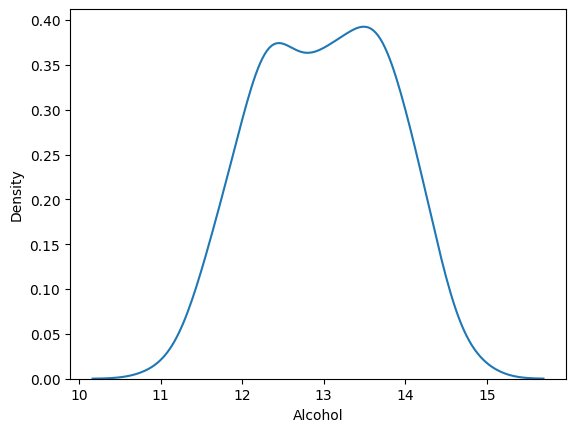

In [12]:
sns.kdeplot(df['Alcohol'])

---

### 🧠 What does this tell us?

This line generates a **Kernel Density Estimate (KDE) plot** for the **Alcohol** feature in your dataset.

---

## 📈 Interpretation: What is the plot telling you?

* The KDE plot is a **smooth curve** that estimates the **probability density function (PDF)** of the `Alcohol` values.
* It helps you visualize the **distribution** of Alcohol content in the wine dataset — similar to a histogram, but smoothed.

---

### 🔍 From the plot, you can observe:

1. **Peak(s)**:

   * Tall, narrow peaks indicate **many wines share similar Alcohol content** around that value.
   * A broader peak indicates **more spread out values**.

2. **Skewness**:

   * If the curve leans to one side, it suggests a **skewed distribution** (right/left).
   * Symmetry implies the data is **roughly normally distributed**.

3. **Multi-modality** (multiple peaks):

   * If there are 2 or 3 humps, it suggests that **different wine classes** might have different Alcohol distributions.
   * That aligns with your dataset having 3 class labels.

---

## ✅ TL;DR:

> **The KDE plot shows you where the Alcohol values are concentrated and how they are spread out across the dataset.**

---

<Axes: xlabel='Malic acid', ylabel='Density'>

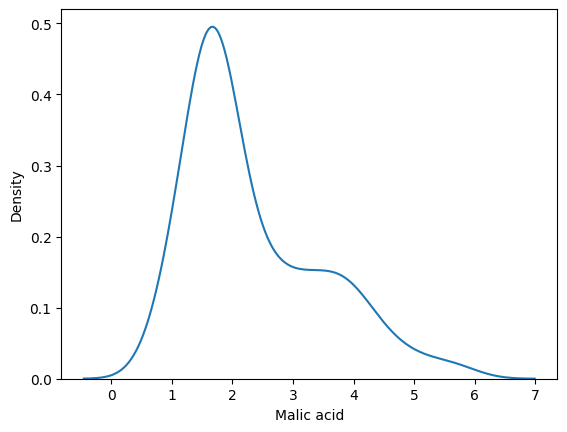

In [13]:
sns.kdeplot(df['Malic acid'])

---

## 📈 What does the plot tell you?

This KDE plot shows the **distribution** of the `Malic acid` values across all wines in your dataset.

---

### 🧠 Interpretation Guide

1. **Peaks (Modes):**

   * A high peak indicates a **common concentration** of malic acid values in that range.
   * If the plot has **multiple peaks**, it may suggest that different wine types have different malic acid profiles.

2. **Spread (Variance):**

   * A **wide curve** implies the malic acid values are spread out.
   * A **narrow curve** means most wines have similar malic acid content.

3. **Skewness:**

   * If the curve is **left-skewed** (tail on the left), it means more wines have higher malic acid.
   * If **right-skewed**, then most wines have lower malic acid, with some high outliers.

---

### 🧪 Compared to Alcohol:

* Malic acid often shows **more variation** than alcohol.
* It may have **less clear separation** between wine classes.
* You might see more **asymmetry** or **outliers**, making it less reliable as a standalone feature for classification.

---

### ✅ TL;DR:

> **The KDE plot for `Malic acid` reveals how frequently certain concentrations occur in the wine samples. It helps assess if `Malic acid` can help differentiate between wine types.**

---


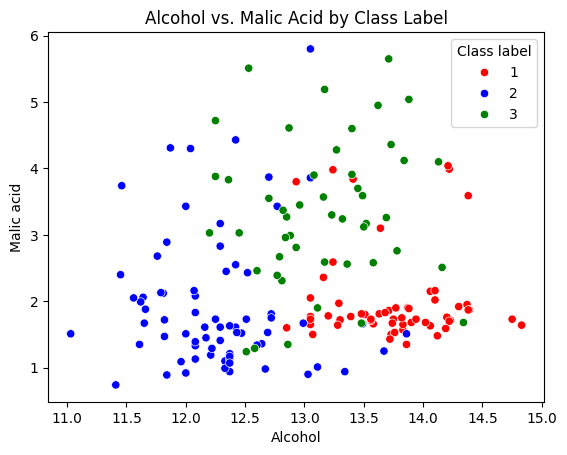

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

color_dict = {1: 'red', 2: 'blue', 3: 'green'}

sns.scatterplot(
    x=df['Alcohol'],
    y=df['Malic acid'],
    hue=df['Class label'],
    palette=color_dict
)

plt.title('Alcohol vs. Malic Acid by Class Label')
plt.show()


In [15]:
# color_dict={1:'red',3:'green',2:'blue'}
# sns.scatterplot(df['Alcohol'],df['Malic acid'],hue=df['Class label'],palette=color_dict)

### ⚙️ Step 1: Do a Train-Test split

Always do a train-test split before applying MinMaxScaling

In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('Class label', axis=1),
                                                    df['Class label'],
                                                    test_size=0.3,
                                                    random_state=0)

X_train.shape, X_test.shape

((124, 2), (54, 2))

### ⚙️ Step 2: Apply Min-Max Scaling with Scikit-Learn

In [17]:
from sklearn.preprocessing import MinMaxScaler

# Step 1: Create the scaler
scaler = MinMaxScaler()

# Step 2: Fit on training data — learns min and max of each feature
scaler.fit(X_train)

# Step 3: Apply scaling to both train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

---

## 🧠 Explanation

### 📌 `MinMaxScaler()`:

Creates a scaler object that rescales features to the default range of **\[0, 1]** using:

$$
x' = \frac{x - x_{\text{min}}}{x_{\text{max}} - x_{\text{min}}}
$$

---

### 📌 `scaler.fit(X_train)`:

* **Learns** the minimum and maximum values of **each feature** in `X_train`.
* These values are saved inside the scaler to be reused for test data (so we don't "peek" at the test set).

---

### 📌 `scaler.transform(...)`:

* Applies the learned min and max to **scale** each value in the dataset.
* Ensures **both training and test sets** are transformed **consistently**.

---

## 🔒 Why fit only on `X_train`?

> To **avoid data leakage** — the model should not "see" or depend on the test data during preprocessing.

---

## 📊 After Scaling

* Every feature in `X_train_scaled` and `X_test_scaled` will now lie between **0 and 1** (unless there are outliers in `X_test` beyond the training range).
* Scaled features are now **unitless**, allowing ML models to converge faster and perform better.

---


### 🧾 Step 3: Restore DataFrame Structure After Scaling

In [18]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

### 🔍 Example Before and After

In [19]:
np.round(X_train.describe(), 1)

,Alcohol,Malic acid
count,124.0,124.0
mean,13.0,2.4
std,0.8,1.1
min,11.0,0.9
25%,12.4,1.6
50%,13.0,1.9
75%,13.6,3.2
max,14.8,5.6


In [20]:
np.round(X_train_scaled.describe(), 1)

,Alcohol,Malic acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


---

📌  **Key difference between Min-Max Scaling and Standard Scaling**

> "...when you do Min-Max Scaling, you're always guaranteed that the minimum becomes 0 and the maximum becomes 1. But you're not guaranteed anything about the mean or standard deviation."

> "...In contrast, Standard Scaling guarantees mean = 0 and std = 1, but **not** min = 0 and max = 1..."

Let’s unpack that.

---

## ⚖️ Min-Max Scaling

### ✅ Formula:

$$
x' = \frac{x - x_{\text{min}}}{x_{\text{max}} - x_{\text{min}}}
$$

### 🔐 Guarantees:

* **Minimum becomes 0**
* **Maximum becomes 1**
* All values are compressed to $[0, 1]$

### 🧨 Not guaranteed:

* Mean (could be anywhere between 0 and 1)

* Standard deviation (depends on how the original values were spread)

---

### 📊 Example

If your original values are: `[50, 100, 150]`

* Min = 50, Max = 150

* After Min-Max Scaling → `[0, 0.5, 1]`

* Mean = $\frac{0 + 0.5 + 1}{3} = 0.5$ ✅

  But if the original values were: `[80, 100, 150]`, the scaled mean **won’t** be 0.5 anymore.

So: ❌ **Mean and std are not controlled.**

---

## 🧮 Standard Scaling (Z-score Normalization)

### ✅ Formula:

$$
x' = \frac{x - \mu}{\sigma}
$$

### 🔐 Guarantees:

* **Mean = 0**
* **Standard deviation = 1**
* Shapes may look similar, but the values are on a new centered scale

### ❌ Not guaranteed:

* Min or Max values — they could be any real number (even negative)

---

## ⚠️ Why Does It Matter?

| Goal                       | Use This Scaler   |
| -------------------------- | ----------------- |
| Values in $[0, 1]$         | ✅ Min-Max Scaling |
| Centered data for PCA, SVM | ✅ StandardScaler  |
| Dealing with outliers      | ✅ RobustScaler    |

---

## 🔍 TL;DR

> **Min-Max Scaling guarantees min = 0 and max = 1 — but the mean and standard deviation vary.**

> **Standard Scaling guarantees mean = 0 and std = 1 — but min and max could be anything.**

---


### 📊 Step 4: Visualize Before and After Min-Max Scaling

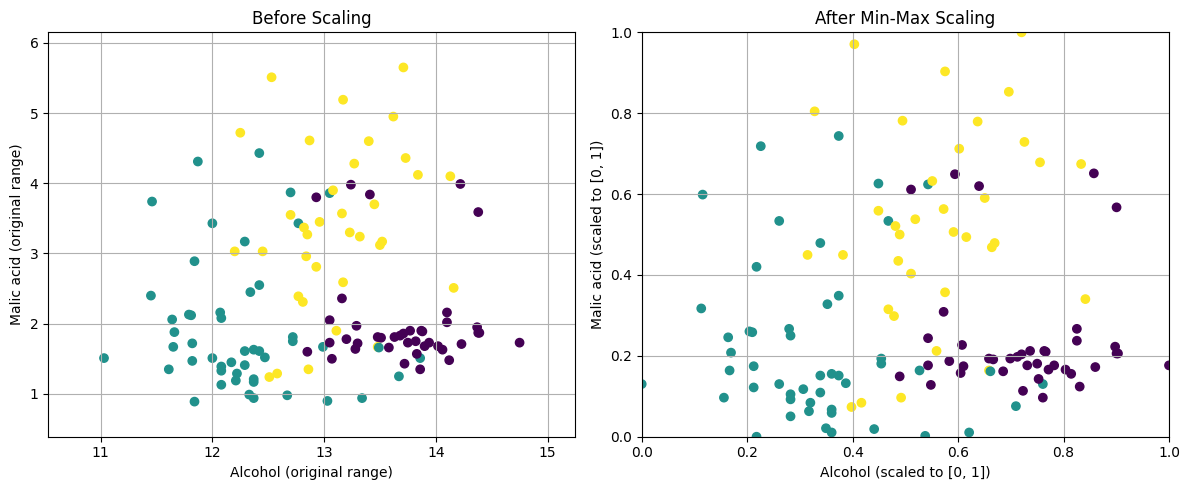

In [25]:
import matplotlib.pyplot as plt

# Create side-by-side plots
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# --- Left: Before Scaling ---
ax1.scatter(X_train['Alcohol'], X_train['Malic acid'], c=y_train, cmap='viridis')
ax1.set_title("Before Scaling")
ax1.set_xlabel("Alcohol (original range)")
ax1.set_ylabel("Malic acid (original range)")
ax1.grid(True)

# Optional: show actual data limits for context
ax1.set_xlim(X_train['Alcohol'].min() - 0.5, X_train['Alcohol'].max() + 0.5)
ax1.set_ylim(X_train['Malic acid'].min() - 0.5, X_train['Malic acid'].max() + 0.5)

# --- Right: After Min-Max Scaling ---
ax2.scatter(X_train_scaled['Alcohol'], X_train_scaled['Malic acid'], c=y_train, cmap='viridis')
ax2.set_title("After Min-Max Scaling")
ax2.set_xlabel("Alcohol (scaled to [0, 1])")
ax2.set_ylabel("Malic acid (scaled to [0, 1])")
ax2.grid(True)

# Axis is now unit square
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.show()

---

## 🎯 Objective

You're visualizing how a 2D feature space (`Alcohol`, `Malic acid`) changes **before and after Min-Max Scaling**.

---

## 🔍 What the Instructor Means

> *“The data is represented in the same way before and after scaling. However, post scaling, it’s squished into a 1×1 scale.”*

---

## 🧠 Formalized Explanation

### ✅ 1. **Geometric Structure is Preserved**

The **relative positions** of the points in the scatter plot stay the same:

* If point A is to the top-right of point B before scaling, it stays that way after scaling.
* This means: **shape, angles, and overall distribution pattern** are preserved.

> 📌 **Scaling is a linear transformation** — it does not distort the geometric relationships between data points.

---

### ✅ 2. **Numerical Ranges are Rescaled**

When you apply **Min-Max Scaling**, the feature values are **linearly mapped to the $[0, 1]$ range**.

Mathematically:

$$
x' = \frac{x - x_{\text{min}}}{x_{\text{max}} - x_{\text{min}}}
$$

As a result:

* `Alcohol` values get rescaled from something like $[11.0, 14.8]$ to $[0, 1]$
* `Malic acid` values from $[0.7, 5.6]$ to $[0, 1]$

So the entire dataset gets **squashed** or **compressed** into a **unit square** — with both axes ranging from 0 to 1.

---

### ✅ 3. **Why "1 × 1 scale"?**

The term “1×1 scale” refers to the **unit square**:

$$
[0, 1] \times [0, 1]
$$

* All points now fit inside this fixed-sized box.
* That’s a **normalized feature space**, ideal for many machine learning algorithms (e.g., gradient descent-based methods, distance-based models like KNN).

---

## 🧾 Summary (Formalized)

> Although Min-Max Scaling changes the numerical range of the features, it preserves the relative positions and geometric structure of the data. The entire dataset is linearly transformed and compressed into a fixed-size unit square $[0, 1] \times [0, 1]$, often referred to as a **1×1 scale**.

---


### 📊 Step 5: Compare Feature Distributions Before vs After Scaling

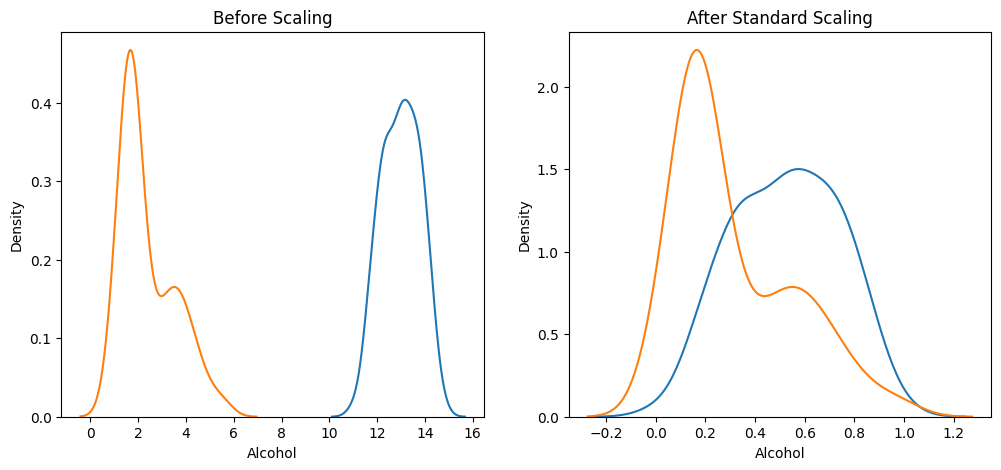

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# KDE plots before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Alcohol'], ax=ax1, label='Alcohol')
sns.kdeplot(X_train['Malic acid'], ax=ax1, label='Malic acid')
ax1.legend()

# KDE plots after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(X_train_scaled['Alcohol'], ax=ax2, label='Alcohol (scaled)')
sns.kdeplot(X_train_scaled['Malic acid'], ax=ax2, label='Malic acid (scaled)')
ax2.legend()

plt.tight_layout()
plt.show()

### 📊 Step 6: Compare Alcohol Distribution Before vs After Scaling

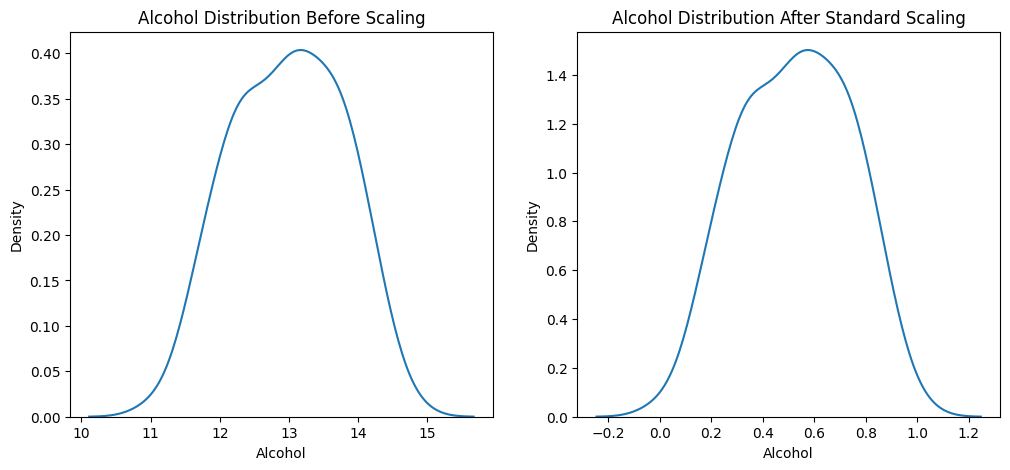

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# Alcohol distribution before scaling
ax1.set_title('Alcohol Distribution Before Scaling')
sns.kdeplot(X_train['Alcohol'], ax=ax1, color='blue')
ax1.set_xlabel('Alcohol (Original)')
ax1.set_ylabel('Density')

# Alcohol distribution after scaling
ax2.set_title('Alcohol Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled['Alcohol'], ax=ax2, color='green')
ax2.set_xlabel('Alcohol (Scaled)')
ax2.set_ylabel('Density')

plt.tight_layout()
plt.show()

### 📊 Step 7: Compare Malic acid Before vs After Scaling

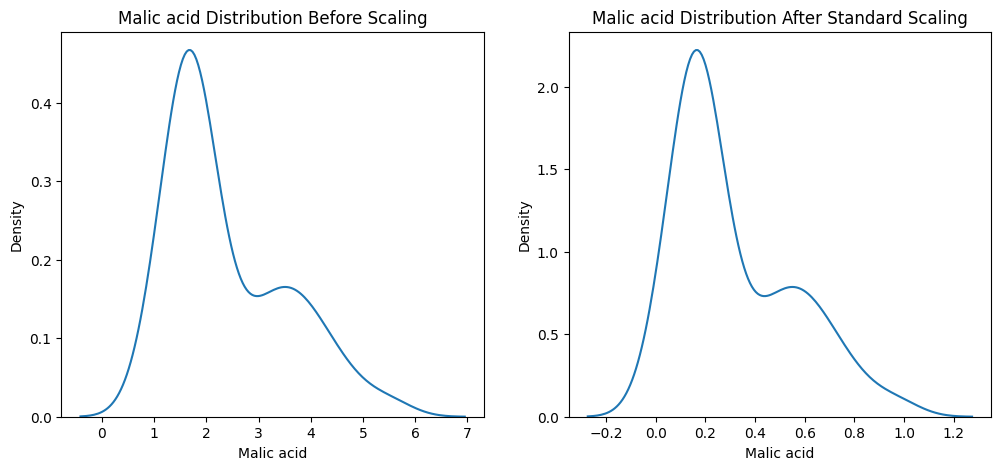

In [24]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Malic acid Distribution Before Scaling')
sns.kdeplot(X_train['Malic acid'], ax=ax1)

# after scaling
ax2.set_title('Malic acid Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled['Malic acid'], ax=ax2)
plt.show()